In [1]:
import re
import pandas as pd
import glob
import os

# Función que permite procesar el log asociado a un experimento y devuelve 3 elementos: 
# el resumen del rendimiento y tiempos en cada dataset, las estadisticas globales y el accuracy por clase.
def procesar_log_detallado(ruta_archivo):

    # Abrimos el archivo en modo lectura
    try:
        with open(ruta_archivo, 'r', encoding='utf-8') as f:
            texto = f.read()
    except FileNotFoundError:
        return f"Error: No se encontró el archivo {ruta_archivo}", None, None

    # Separamos el log por secciones asociadas a cada dataset
    secciones = re.split(r"\*{20,}Ejecutando prueba sobre el dataset", texto)
    
    resumen_data = []
    clases_data = []
    
    # Recorremos las secciones del log asociadas a cada dataset
    for seccion in secciones[1:]:
        # 1. Obtenemos el nombre del dataset
        lineas = seccion.strip().split('\n')
        dataset_name = lineas[0].split('*')[0].strip()
        
        # 2. Extraemos el OA y AA finales obtenidos sobre el dataset
        oa_match = re.search(r"OA Final:\s*([\d.]+)%\s*±\s*([\d.]+)%", seccion)
        aa_match = re.search(r"AA Final:\s*([\d.]+)%\s*±\s*([\d.]+)%", seccion)
        
        #2.5 Extraemos las medidas de tiempo
        tiempo_total_match = re.search(r"Tiempo entrenamiento total medio .*?:\s*([\d.]+)\s*s", seccion)
        tiempo_epoca_match = re.search(r"Tiempo medio por época .*?:\s*([\d.]+)\s*s", seccion)
        
        # Si se han encontrado el OA y el AA se añaden al resumen de resultados
        if oa_match and aa_match:
            datos_dataset = {
                "Dataset": dataset_name,
                "OA (%)": float(oa_match.group(1)),
                "std OA (%)": float(oa_match.group(2)),
                "AA (%)": float(aa_match.group(1)),
                "std AA (%)": float(aa_match.group(2))
            }
            
            # Añadimos los tiempos si los encuentra (por si algún log antiguo no los tiene)
            if tiempo_total_match:
                datos_dataset["Tiempo Total (s)"] = float(tiempo_total_match.group(1))
            else:
                datos_dataset["Tiempo Total (s)"] = None
                
            if tiempo_epoca_match:
                datos_dataset["Tiempo por Época (s)"] = float(tiempo_epoca_match.group(1))
            else:
                datos_dataset["Tiempo por Época (s)"] = None

            resumen_data.append(datos_dataset)
            
        # 3. Extraemos el accuracy obtenido para cada clase
        bloque_clases = re.search(r"ACCURACY POR CLASE:(.*?)---", seccion, re.DOTALL)
        if bloque_clases:
            # Obtenemos los resultados para cada clase (ignorando la desviación típica de la clase)
            matches_clase = re.findall(r"Clase (\d+):\s*([\d.]+)%", bloque_clases.group(1))
            # Almacenamos el accuracy asociado a cada una de las clases
            for num_clase, valor_acc in matches_clase:
                clases_data.append({
                    "Dataset": dataset_name,
                    "Clase": f"Clase {num_clase}",
                    "Accuracy (%)": float(valor_acc)
                })
    
    # Si no se han encontrado datos válidos se devuelve un mensaje de error.
    if not resumen_data:
        return "No se encontraron datos válidos.", None, None

    # Convertimos las listas en dataframes
    df_resumen = pd.DataFrame(resumen_data)
    df_clases_long = pd.DataFrame(clases_data)
    
    # Transformamos la tabla de clases a formato ancho
    df_clases_wide = df_clases_long.pivot(index='Dataset', columns='Clase', values='Accuracy (%)')
    
    # Calculamos las estadísticas globales
    stats = {
        "Métrica": ["OA Global", "AA Global", "Tiempo Total (s)", "Tiempo por Época (s)"],
        "Media (%)": [df_resumen["OA (%)"].mean(), df_resumen["AA (%)"].mean(),df_resumen["Tiempo Total (s)"].mean(),df_resumen["Tiempo por Época (s)"].mean()],
        "Desviación (%)": [df_resumen["OA (%)"].std(), df_resumen["AA (%)"].std(), df_resumen["Tiempo Total (s)"].std(),df_resumen["Tiempo por Época (s)"].std()]
    }
    
    # Pasamos las estadísticas a un dataframe
    df_stats = pd.DataFrame(stats)
    
    return df_resumen, df_stats, df_clases_wide

In [2]:
def imprimirResultados(ruta_carpeta):
    #Obtenemos los ficheros que terminan en .log
    archivos = glob.glob(os.path.join(ruta_carpeta, "*.log"))

    datos_comparacion = []

    if not archivos:
        print(f"No se encontraron archivos .log en la carpeta '{ruta_carpeta}'.")
    else:
        #Recorremos cada uno de los archivos asociados a las distintas ejecuciones
        for archivo in archivos:
            #Obtenemos el nombre asociado a la prueba
            nombre_prueba = os.path.basename(archivo)
            
            print(f"\n{'='*30} ARCHIVO: {nombre_prueba} {'='*30}")

            nombre_prueba = os.path.basename(archivo).replace(".log", "").replace("resultados_", "")
            
            #Procesamos el log asociado a la prueba
            df_res, df_st, df_clases = procesar_log_detallado(archivo)
            
            #Si se leyeron correctamente los datos pasamos a imprimirlos por pantalla y a almacenarlos en datos_comparacion para poder graficar los resultados
            if isinstance(df_res, pd.DataFrame):
                print("\n************* TABLA RESUMEN (OA/AA): *************")
                print(df_res.to_string(index=False))
                
                print("\n************* ACCURACY POR CLASE POR DATASET: *************")
                print(df_clases.fillna("-").to_string())
                
                print("\n************* ESTADÍSTICAS GLOBALES: *************")
                print(df_st.to_string(index=False))
                
                #Guardamos los datos necesarios para realizar la gráfica (medias y desviaciones)
                oa_global = df_st.loc[df_st['Métrica'] == 'OA Global', 'Media (%)'].values[0]
                aa_global = df_st.loc[df_st['Métrica'] == 'AA Global', 'Media (%)'].values[0]
                
                oa_std = df_st.loc[df_st['Métrica'] == 'OA Global', 'Desviación (%)'].values[0]
                aa_std = df_st.loc[df_st['Métrica'] == 'AA Global', 'Desviación (%)'].values[0]

                t_total_medio = df_res["Tiempo Total (s)"].mean() if "Tiempo Total (s)" in df_res.columns else None
                t_epoca_medio = df_res["Tiempo por Época (s)"].mean() if "Tiempo por Época (s)" in df_res.columns else None
                
                datos_comparacion.append({
                    "Prueba": nombre_prueba,
                    "OA Global (%)": oa_global,
                    "AA Global (%)": aa_global,
                    "OA Std (%)": oa_std,
                    "AA Std (%)": aa_std,
                    "Tiempo Total Medio (s)": t_total_medio,
                    "Tiempo Época Medio (s)": t_epoca_medio
                })
            else:
                print(df_res)

        if datos_comparacion:
            datos_ordenados = sorted(
                datos_comparacion, 
                key=lambda x: (x["AA Global (%)"], x["OA Global (%)"]), 
                reverse=True
            )
            
            
            
            # Definimos anchos fijos
            w_rank = 8
            w_metodo = 40  
            w_oa = 22
            w_aa = 22

            print(f"\n\n{'='*30} RESUMEN RESULTADOS {'='*30}")

            # Encabezado
            header = f"{'Ranking':<{w_rank}} | {'Método':<{w_metodo}} | {'OA Global (%) ± Std':<{w_oa}} | {'AA Global (%) ± Std':<{w_aa}}"
            print(header)
            print("-" * len(header))

            # Filas
            for i, dato in enumerate(datos_ordenados, start=1):
                oa_str = f"{dato['OA Global (%)']:.2f} ± {dato['OA Std (%)']:.2f}"
                aa_str = f"{dato['AA Global (%)']:.2f} ± {dato['AA Std (%)']:.2f}"
                
                # Usamos las mismas variables de ancho (w_rank, w_metodo, etc.)
                print(f"#{i:<{w_rank-1}} | {dato['Prueba']:<{w_metodo}} | {oa_str:<{w_oa}} | {aa_str:<{w_aa}}")

            print("=" * len(header))
    
        return datos_comparacion

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

def graficaComparacionModelos(datos_comparacion):
    if datos_comparacion:
        # Creamos una copia para proteger el DataFrame original de advertencias (SettingWithCopy)
        df_comparacion = pd.DataFrame(datos_comparacion).copy()

        if 'AA Global (%)' in df_comparacion.columns:
            df_comparacion = df_comparacion.sort_values(by='AA Global (%)', ascending=False)
        
        # REGLA ESTÉTICA: Reemplazar guiones bajos por espacios en los nombres de las pruebas
        if 'Prueba' in df_comparacion.columns:
            df_comparacion['Prueba'] = df_comparacion['Prueba'].str.replace('_', ' ')
        
        # Comprobamos si los tiempos se han extraído correctamente y no son todos nulos
        tiene_tiempos = "Tiempo Total Medio (s)" in df_comparacion.columns and not df_comparacion["Tiempo Total Medio (s)"].isnull().all()
        
        num_graficas = 3 if tiene_tiempos else 2
        # Proporcionamos dimensiones óptimas (13x6.5 por bloque) para albergar las etiquetas bien
        fig, axes = plt.subplots(num_graficas, 1, figsize=(13, 6.5 * num_graficas))
        
        # Asignamos los ejes base
        ax1 = axes[0]
        ax2 = axes[1]

        # ---------------------------------------------------------
        # 1. Gráfica de Precisión
        # ---------------------------------------------------------
        df_comparacion.set_index('Prueba')[['OA Global (%)', 'AA Global (%)']].plot(
            kind='bar', ax=ax1, color=['#1f77b4', '#ff7f0e'], alpha=0.8, width=0.75
        )
        ax1.set_title('Media Precisión Global (OA y AA)', fontsize=14, fontweight='bold', pad=15)
        ax1.set_ylabel('Precisión (%)', fontsize=11)
        ax1.set_ylim(80, 103) # Margen extra arriba para evitar colisiones con las etiquetas
        
        ax1.set_axisbelow(True)
        ax1.grid(axis='y', linestyle='--', alpha=0.5)
        ax1.legend(["OA Global", "AA Global"], loc='upper right')
        
        # AGREGAR VALORES ENCIMA DE LAS BARRAS
        for container in ax1.containers:
            ax1.bar_label(container, fmt='%.1f%%', padding=3, fontsize=8.5, fontweight='semibold')
            
        # Ajuste individual del Eje X para corregir el bug de desalineación
        ax1.set_xticklabels(ax1.get_xticklabels(), rotation=35, ha='right', fontsize=9.5)
        ax1.set_xlabel('') # Ocultamos la etiqueta intermedia para limpiar el diseño

        # ---------------------------------------------------------
        # 2. Gráfica de Desviación
        # ---------------------------------------------------------
        df_comparacion.set_index('Prueba')[['OA Std (%)', 'AA Std (%)']].plot(
            kind='bar', ax=ax2, color=['#2ca02c', '#d62728'], alpha=0.8, width=0.75
        )
        ax2.set_title('Desviación estándar (OA y AA)', fontsize=14, fontweight='bold', pad=15)
        ax2.set_ylabel('Variación (%)', fontsize=11)
        
        # Ajuste dinámico del límite superior de desviación
        valores_std = df_comparacion[['OA Std (%)', 'AA Std (%)']].values
        ymax_std = valores_std[valores_std > 0].max() * 1.15 if valores_std.size else 5
        ax2.set_ylim(bottom=0, top=ymax_std)
        
        ax2.set_axisbelow(True)
        ax2.grid(axis='y', linestyle='--', alpha=0.5)
        ax2.legend(["OA Std", "AA Std"], loc='upper right')
        
        # AGREGAR VALORES ENCIMA DE LAS BARRAS
        for container in ax2.containers:
            ax2.bar_label(container, fmt='%.2f', padding=3, fontsize=8.5, fontweight='semibold')
            
        # Ajuste individual del Eje X
        ax2.set_xticklabels(ax2.get_xticklabels(), rotation=35, ha='right', fontsize=9.5)
        
        if tiene_tiempos:
            ax2.set_xlabel('')
        else:
            ax2.set_xlabel('Experimentos', fontsize=11, labelpad=10)

        # ---------------------------------------------------------
        # 3. Gráfica de Tiempos (SOLO TIEMPO POR ÉPOCA)
        # ---------------------------------------------------------
        if tiene_tiempos:
            ax3 = axes[2]
            
            df_comparacion.set_index('Prueba')[['Tiempo Época Medio (s)']].plot(
                kind='bar', ax=ax3, color=['#8c564b'], alpha=0.8, width=0.4
            )
            ax3.set_title('Coste Computacional (Tiempo Medio por Época)', fontsize=14, fontweight='bold', pad=15)
            ax3.set_ylabel('Tiempo (segundos)', fontsize=11)
            ax3.set_xlabel('Experimentos', fontsize=11, labelpad=10)

            # Margen dinámico superior
            ax3.set_ylim(bottom=0, top=df_comparacion['Tiempo Época Medio (s)'].max() * 1.15)

            ax3.set_axisbelow(True)
            ax3.grid(axis='y', linestyle='--', alpha=0.5)
            ax3.legend(["Tiempo Medio por Época"], loc='upper right')
            
            # AGREGAR VALORES ENCIMA DE LAS BARRAS
            for container in ax3.containers:
                ax3.bar_label(container, fmt='%.1fs', padding=3, fontsize=8.5, fontweight='semibold')
                
            # Ajuste individual del Eje X para el bloque inferior final
            ax3.set_xticklabels(ax3.get_xticklabels(), rotation=35, ha='right', fontsize=9.5)

        plt.tight_layout()
        plt.show()

## Resultados

In [4]:

ruta_carpeta = "resultadosPruebasVIT"

datos_orig=imprimirResultados(ruta_carpeta)


============================== ARCHIVO: resultados_VIT+CUTMIX.log ==============================

************* TABLA RESUMEN (OA/AA): *************
        Dataset  OA (%)  std OA (%)  AA (%)  std AA (%)  Tiempo Total (s)  Tiempo por Época (s)
        oitaven   96.28        0.28   94.11        0.62            740.30                7.4030
     das_mestas   91.02        0.14   89.69        0.22           1325.27               13.2527
      eiras_dam   95.30        0.39   91.00        1.27            517.55                5.1755
  ermidas_creek   98.51        0.15   97.00        0.41            806.25                8.0625
ferreiras_river   91.94        0.12   82.12        2.31           1836.75               18.3675
     mera_river   91.22        0.04   91.16        1.43           2018.52               20.1852
           ulla   97.62        1.00   96.87        1.86             54.29                0.5429
          xesta   98.83        0.05   94.89        1.49           2057.43         

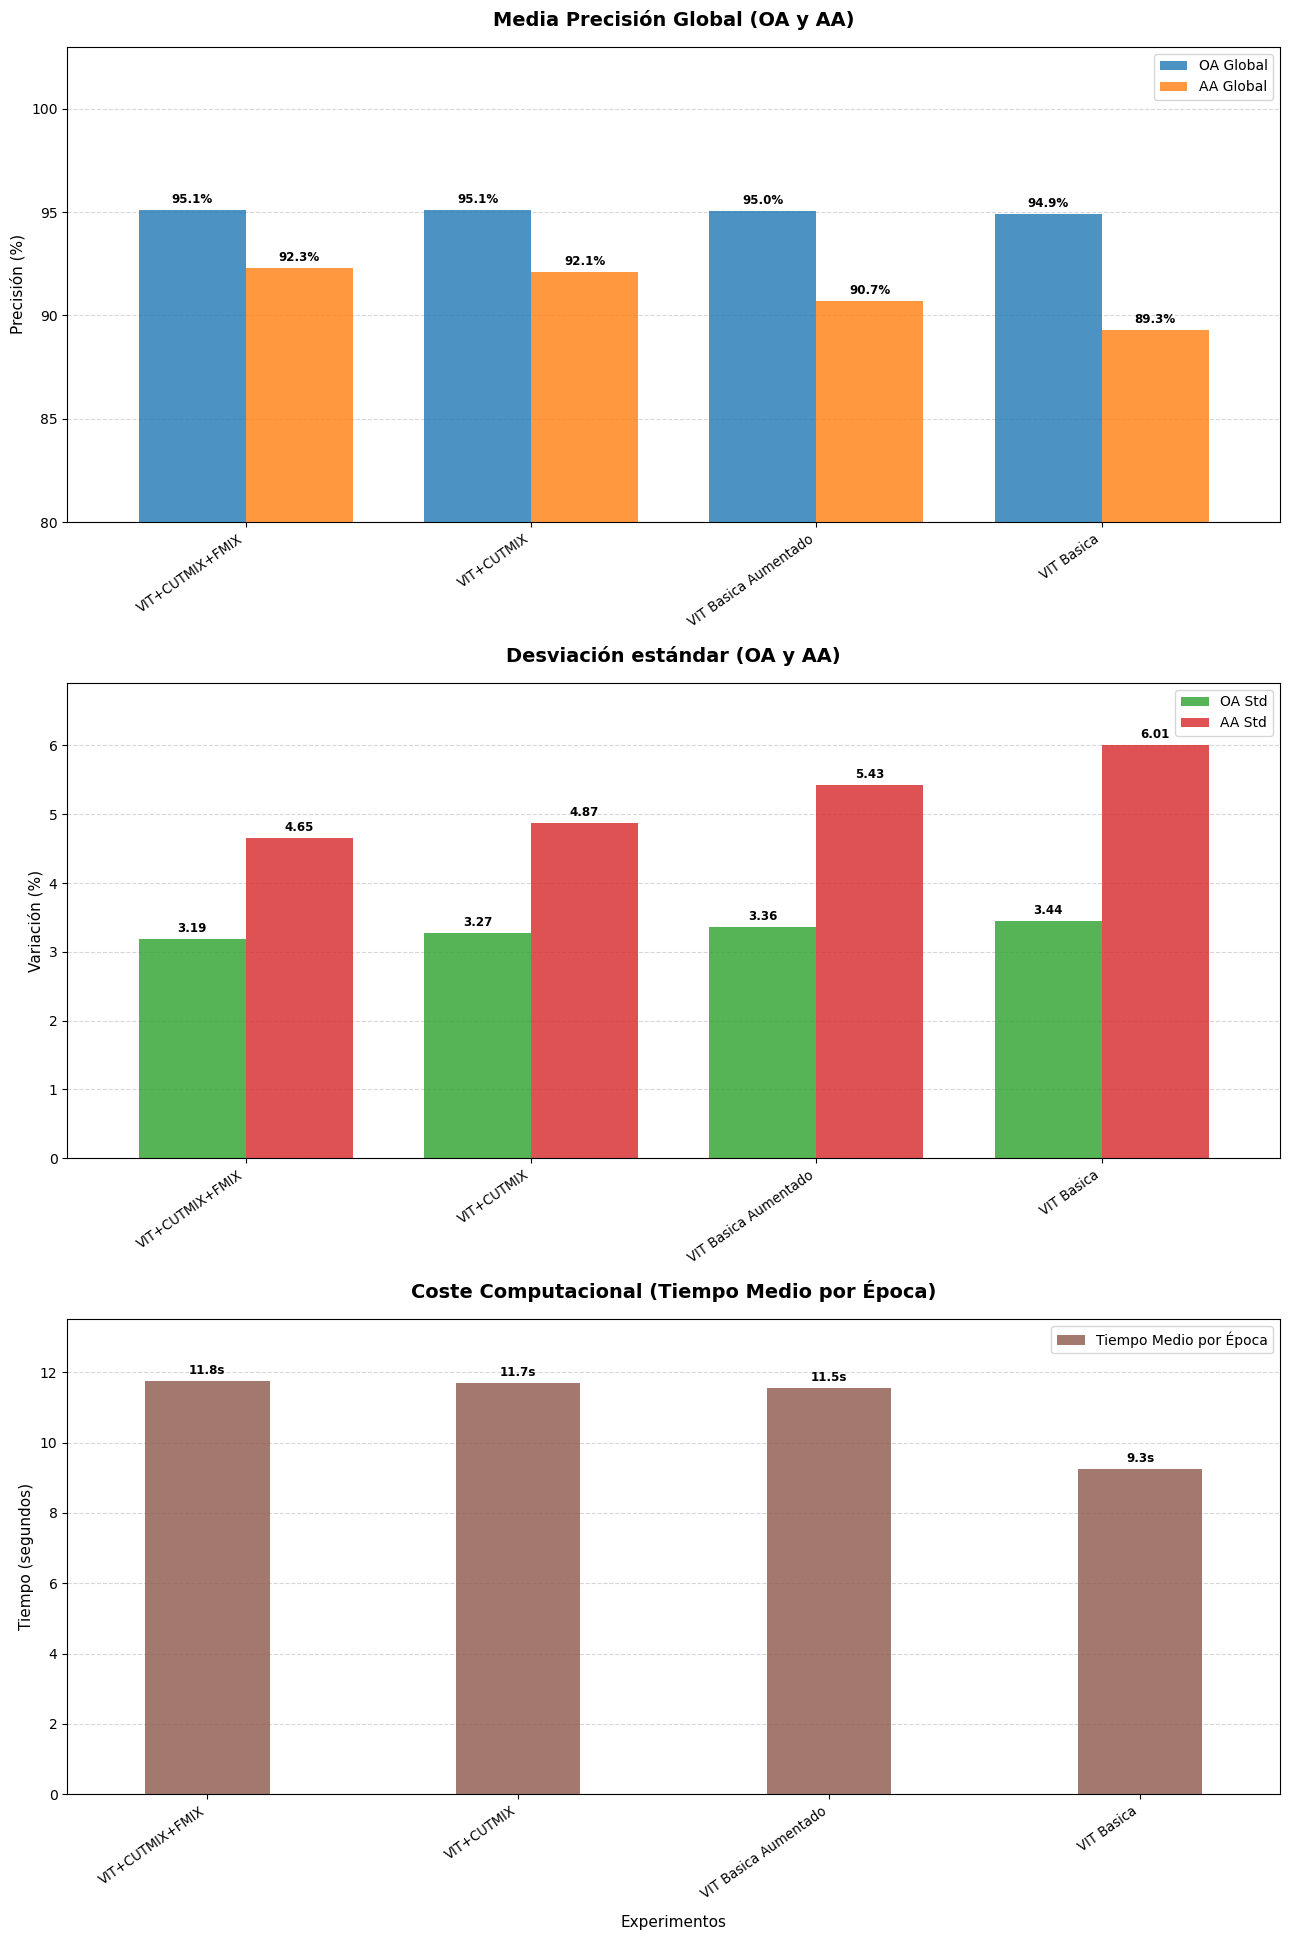

In [5]:
graficaComparacionModelos(datos_orig)

# Comportamiento de las distintas versiones por cada dataset

In [6]:
# DICCIONARIO GLOBAL DE COLORES
PALETA_COLORES = {
    # FASE 1:
    # CNN Básica
    "CNN_Basica": "#6baed6",                 
    "CNN_Basica_PyTorch": "#6baed6",
    "CNN_Basica_Aum": "#1f77b4",             
    "CNN_Basica_Aumento": "#1f77b4",
    
    #CutMix
    "CUTMIX": "#a1d99b",                     
    "CUTMIX_PyTorch": "#a1d99b",
    "CUTMIX_Aum": "#2ca02c",                 
    "CUTMIX_Aumento": "#2ca02c",
    
    #FMix
    "FMIX": "#c49c94",                       
    "FMIX_PyTorch": "#c49c94",
    "FMIX_Aum": "#8c564b",                   
    "FMIX_Aumento": "#8c564b",
    
    #MixUp
    "MIXUP": "#c7c7c7",                      
    "MIXUP_PyTorch": "#c7c7c7",
    "MIXUP_Aum": "#7f7f7f",                  
    "MIXUP_Aumento": "#7f7f7f",
    
    #CutMix + FMix
    "CUTMIX_FMIX": "#9edae5",                
    "CUTMIX_FMIX_PyTorch": "#9edae5",
    "CUTMIX_FMIX_Aum": "#17becf",            
    "CUTMIX_FMIX_Aumento": "#17becf",


    # FASES 3 y 4
    "VIT_Basica": "#e377c2",                
    "VIT_Basica_Aumentado": "#9467bd",       
    "VIT+CUTMIX": "#ff7f0e",                 
    "VIT+CUTMIX+FMIX": "#d62728",            

    # FASE 2
    "0, Flips": "#bcbd22",                   
    "1, Rotación": "#aec7e8",
    "3, Rotación_Zoom": "#ffbb78",
    "11, Rotación_Borrado Aleatorio": "#f7b6d2",
    "12, Rotación_Zoom_Borrado Aleatorio": "#dbdb8d"
}

Datasets detectados: ['das_mestas', 'eiras_dam', 'ermidas_creek', 'ferreiras_river', 'mera_river', 'oitaven', 'ulla', 'xesta']

Generando gráficas para: das_mestas...


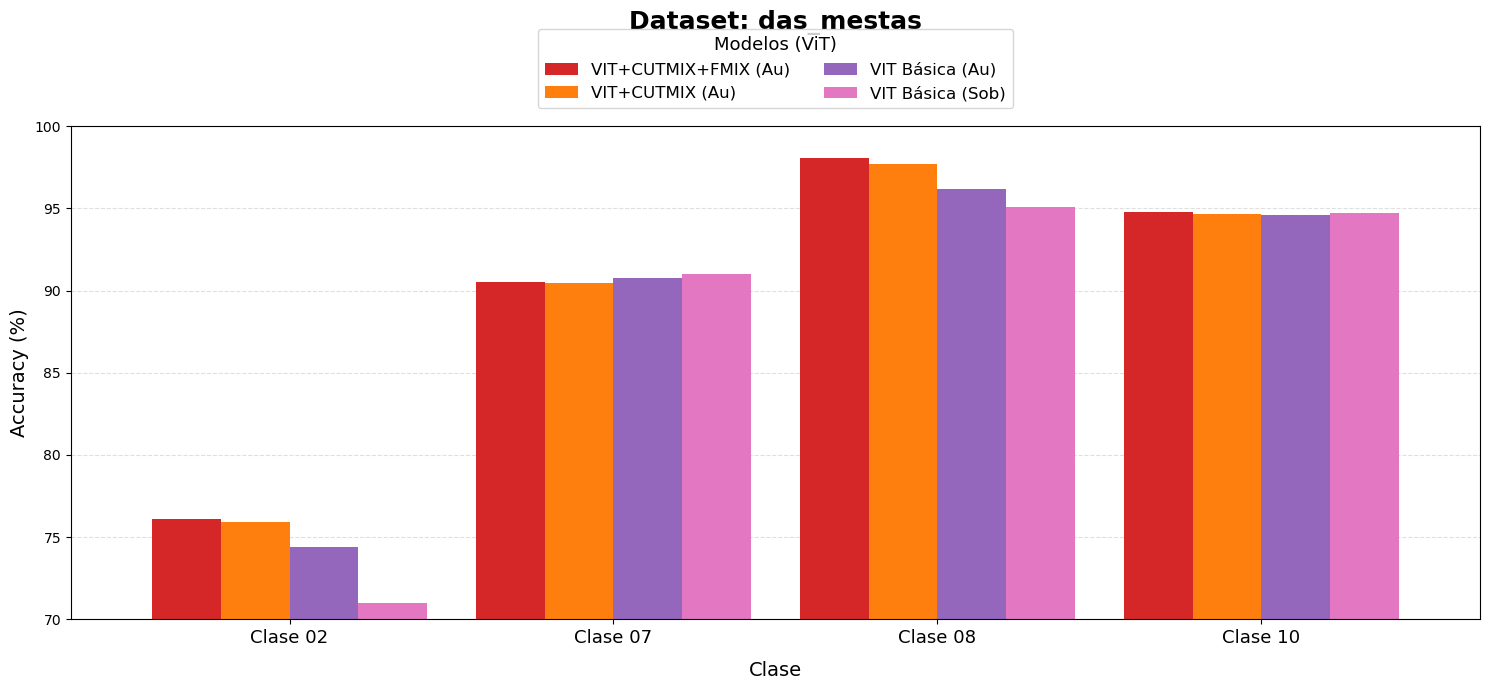


Generando gráficas para: eiras_dam...


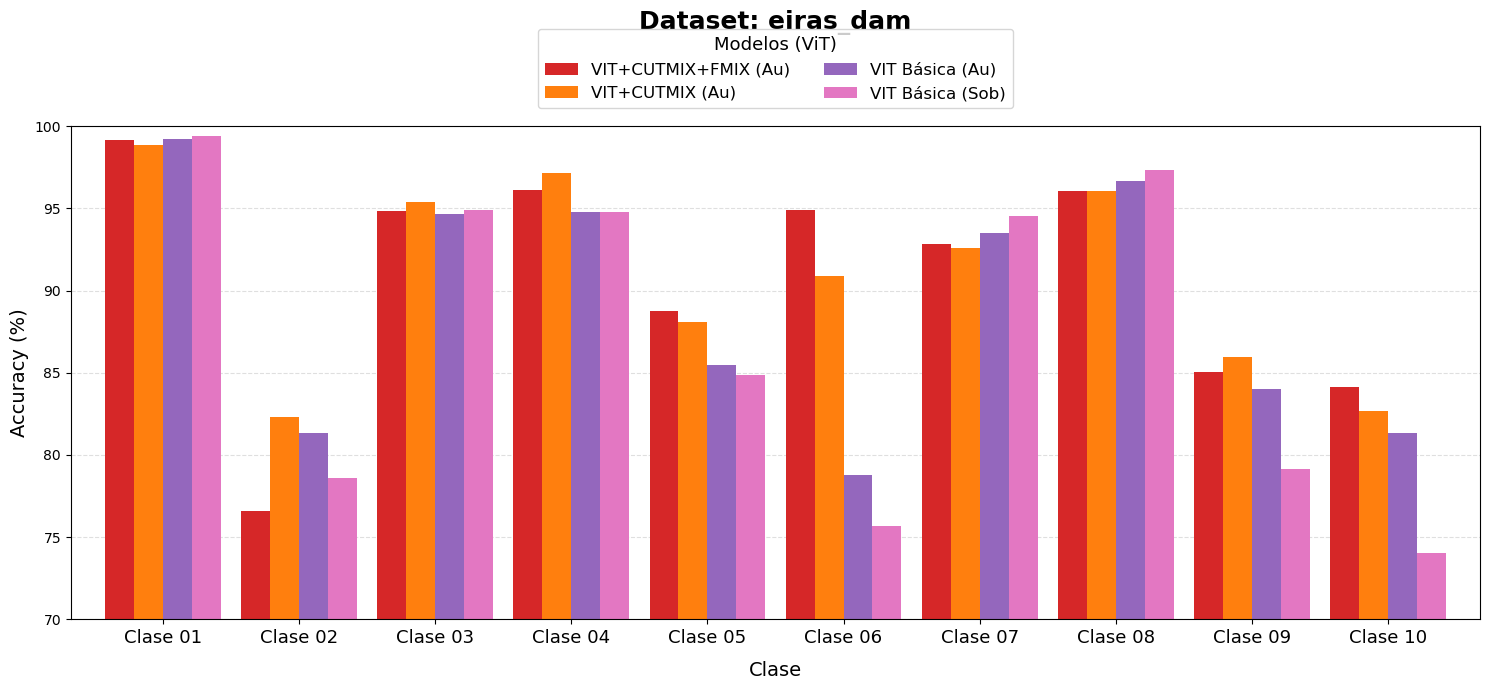


Generando gráficas para: ermidas_creek...


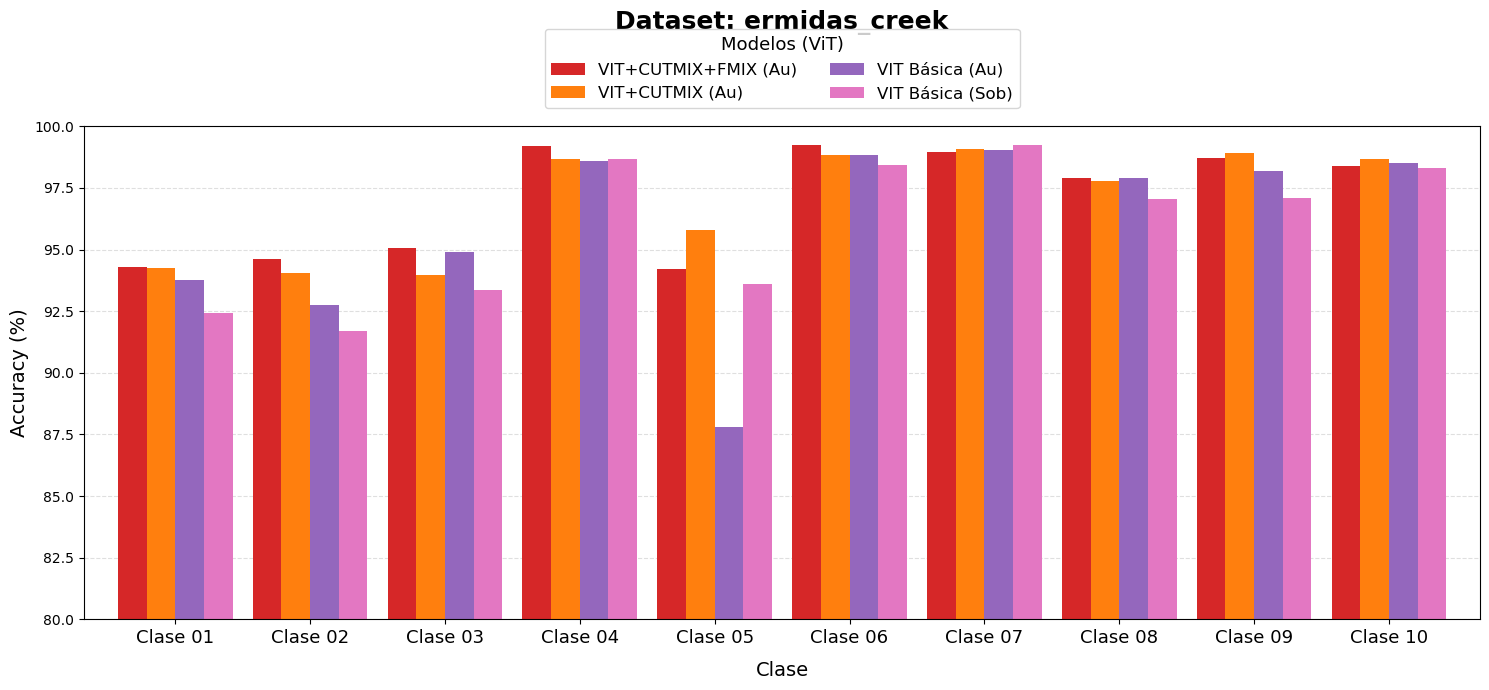


Generando gráficas para: ferreiras_river...


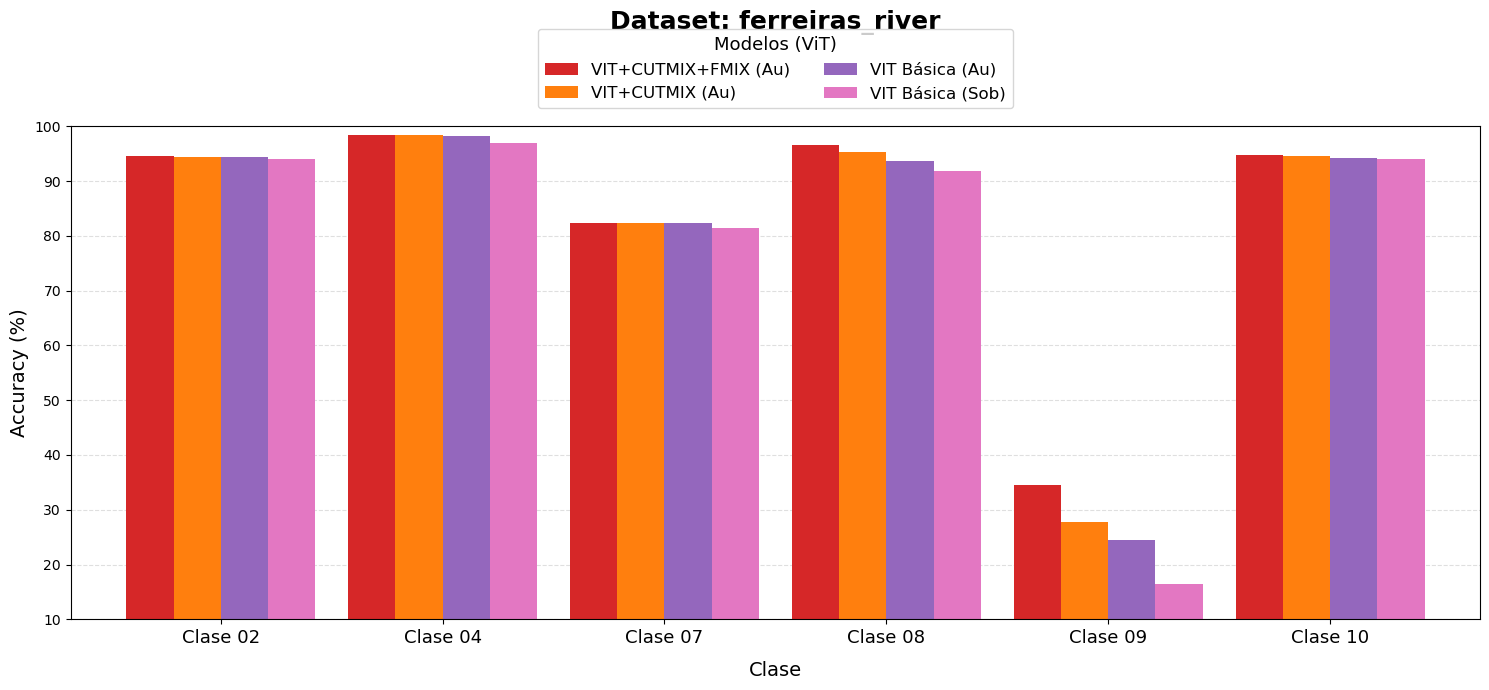


Generando gráficas para: mera_river...


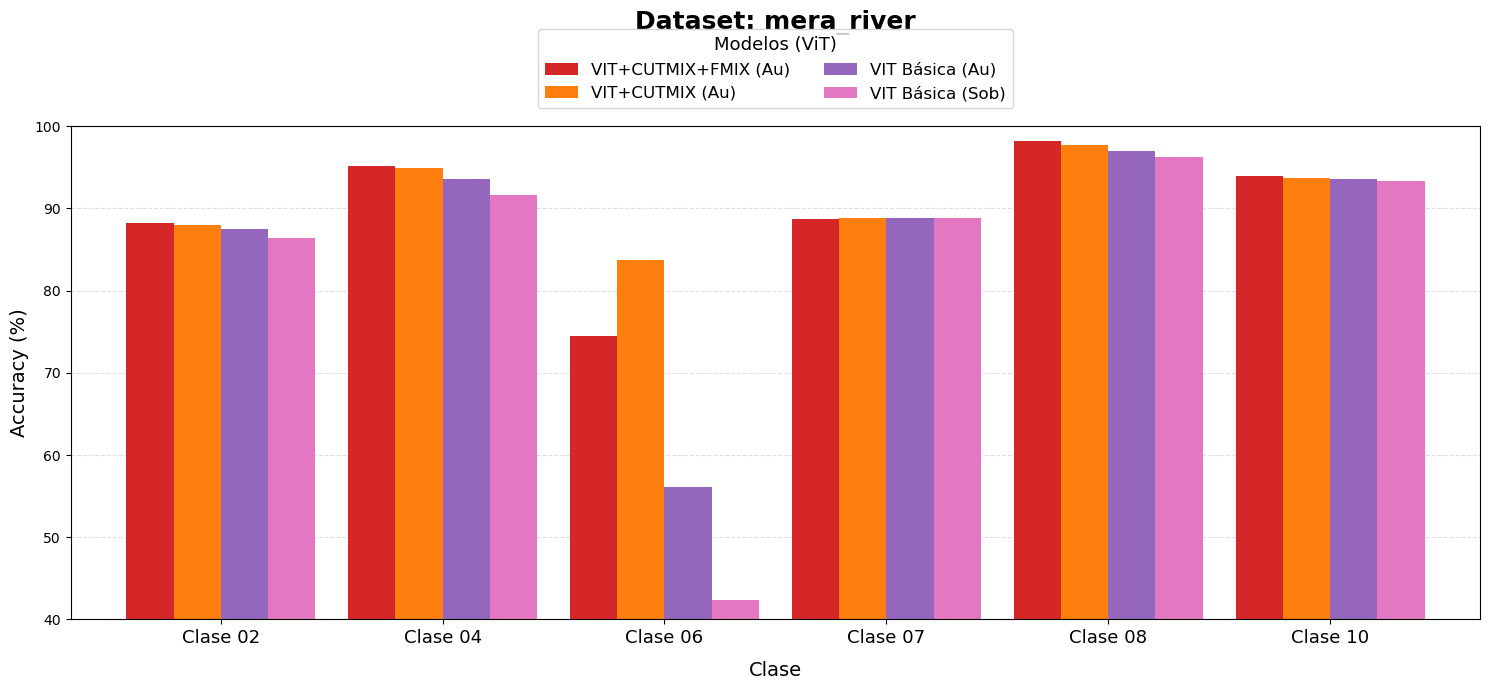


Generando gráficas para: oitaven...


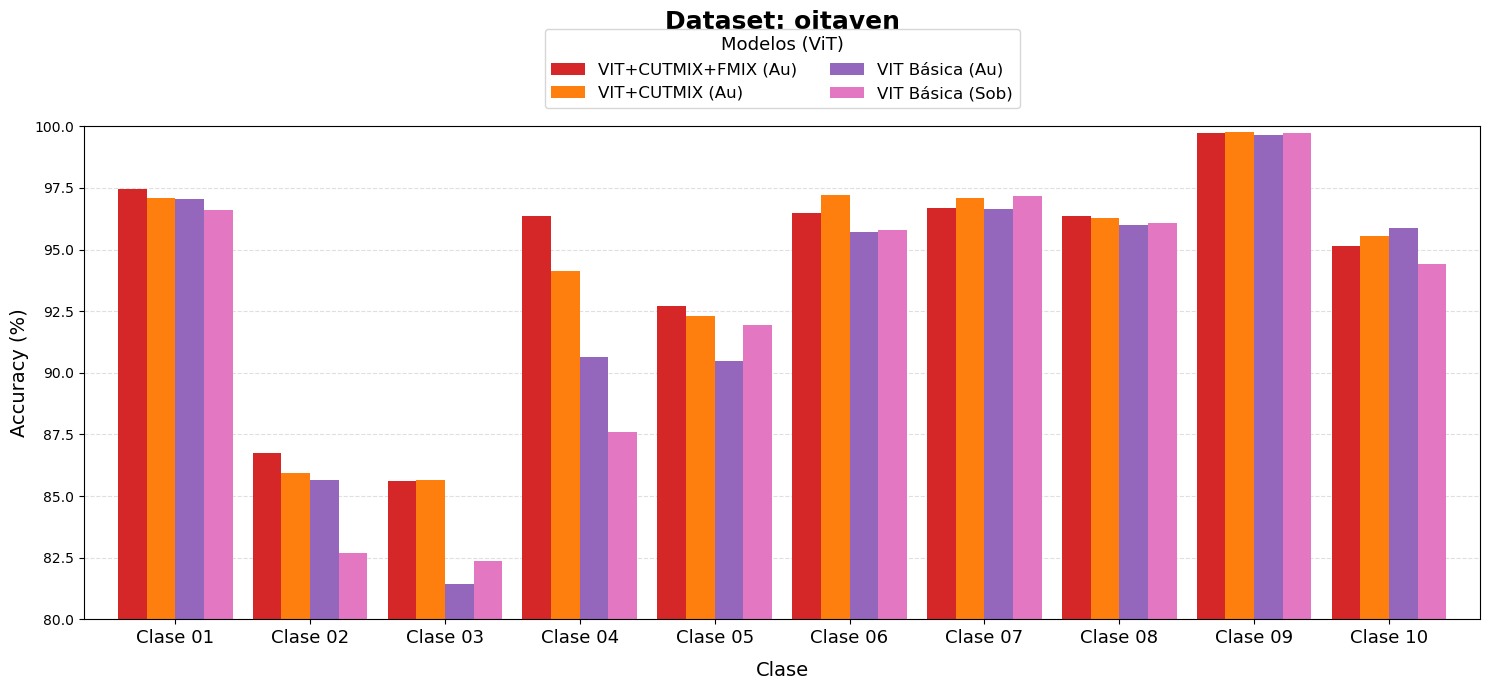


Generando gráficas para: ulla...


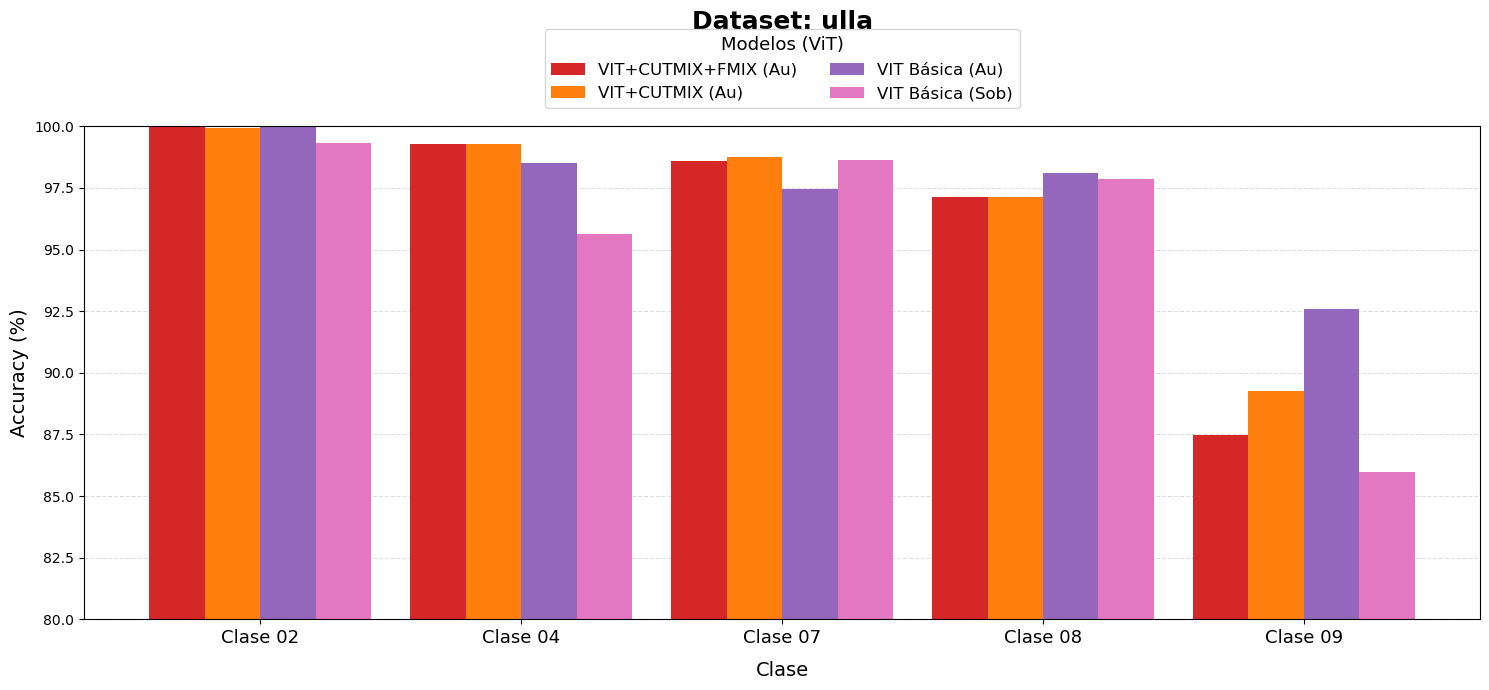


Generando gráficas para: xesta...


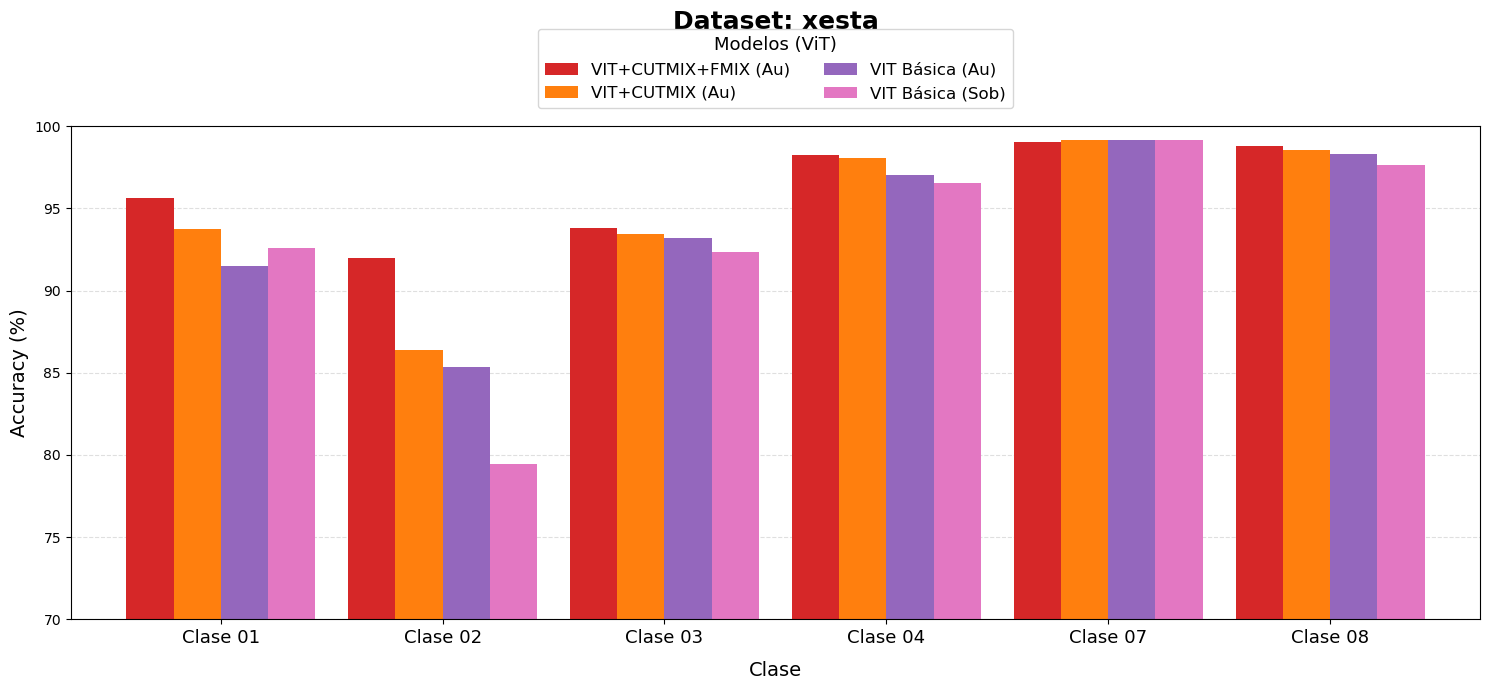

In [7]:
import glob
import math
import os
import matplotlib.pyplot as plt
import pandas as pd

# Graficar resultados por dataset individual
def graficar_clases_separado_limpio(dataset_objetivo):
    modelos_base = ["VIT+CUTMIX", "VIT+CUTMIX+FMIX", "VIT_Basica_Aumentado", "VIT_Basica"]
    df_original = pd.DataFrame()

    # Recolectar datos
    for modelo in modelos_base:
        ruta_orig = os.path.join("resultadosPruebasVIT", f"resultados_{modelo}.log")
        
        if os.path.exists(ruta_orig):
            _, _, df_clases_orig = procesar_log_detallado(ruta_orig)
            if df_clases_orig is not None and dataset_objetivo in df_clases_orig.index:
                df_original[modelo] = df_clases_orig.loc[dataset_objetivo]

    if df_original.empty:
        print(f"No hay datos para el dataset: {dataset_objetivo}")
        return

    # Filtrar clases nulas o vacías
    df_original = df_original.dropna(how='all') 
    df_original = df_original[(df_original > 0).any(axis=1)] 

    if df_original.empty:
        print(f"No hay datos válidos tras el filtrado para {dataset_objetivo}")
        return

    # Ordenar columnas según ranking global
    orden_ranking = ["VIT+CUTMIX+FMIX", "VIT+CUTMIX", "VIT_Basica_Aumentado", "VIT_Basica"]
    cols_validas = [c for c in orden_ranking if c in df_original.columns]
    df_original = df_original[cols_validas]

    # Calcular límite inferior dinámico
    todos_valores = df_original.values.flatten()
    valores_validos = [v for v in todos_valores if v > 0 and not pd.isna(v)]
    ymin = (min(valores_validos) // 10) * 10 if valores_validos else 0

    # Generar gráfica
    fig, ax1 = plt.subplots(1, 1, figsize=(15, 7)) 

    # Asignar colores fijos 
    colores_plot = [PALETA_COLORES.get(col, "#d3d3d3") for col in df_original.columns]
    
    df_original.plot(kind='bar', ax=ax1, width=0.85, color=colores_plot)
    
    # Configurar título y etiquetas
    ax1.set_title(f'Dataset: {dataset_objetivo}', fontsize=18, fontweight='bold', pad=70)
    ax1.set_ylabel('Accuracy (%)', fontsize=14)
    ax1.set_xlabel('Clase', fontsize=14, labelpad=10)
    ax1.set_ylim(ymin, 100) 
    
    # Configurar rejilla
    ax1.set_axisbelow(True)
    ax1.grid(axis='y', linestyle='--', alpha=0.4)
        
    # Formatear etiquetas del eje X
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0, ha='center', fontsize=13)
    
    # Limpiar etiquetas y añadir sufijos dinámicos
    labels_limpios = []
    for col in df_original.columns:
        lbl = col.replace('_Basica', ' Básica').replace('_Aumentado', ' (Au)')
        if "CUTMIX" in col:
            lbl += " (Au)"
        if lbl == "VIT Básica":
            lbl += " (Sob)"
        labels_limpios.append(lbl)

    # Configurar leyenda
    ax1.legend(
        labels=labels_limpios,
        title="Modelos (ViT)", 
        loc='lower center', 
        bbox_to_anchor=(0.5, 1.02), 
        ncol=2,
        fontsize=12,
        title_fontsize=13
    )

    plt.tight_layout()
    plt.show()

# Obtener lista de datasets desde logs
def obtener_lista_datasets():
    archivos = glob.glob(os.path.join("resultadosPruebasVIT", "*.log"))
    if not archivos:
        return []
    
    _, _, df_clases = procesar_log_detallado(archivos[0])
    if df_clases is not None:
        return df_clases.index.tolist()
    return []

# Ejecución principal
datasets_disponibles = obtener_lista_datasets()

if not datasets_disponibles:
    print("No se detectaron datasets en los archivos de log de ViT.")
else:
    print(f"Datasets detectados: {datasets_disponibles}")
    for ds in datasets_disponibles:
        print(f"\nGenerando gráficas para: {ds}...")
        graficar_clases_separado_limpio(ds)

In [8]:
import glob
import os
import pandas as pd

# Imprimir tabla de clases por dataset
def imprimir_tabla_clases_separado_limpio(dataset_objetivo):
    modelos_base = ["VIT+CUTMIX", "VIT+CUTMIX+FMIX", "VIT_Basica_Aumentado", "VIT_Basica"]
    filas_datos = {}

    # Recolectar datos
    for modelo in modelos_base:
        ruta_orig = os.path.join("resultadosPruebasVIT", f"resultados_{modelo}.log")
        
        if os.path.exists(ruta_orig):
            # Extraer variables del log
            _, _, df_clases_orig = procesar_log_detallado(ruta_orig)
            if df_clases_orig is not None and dataset_objetivo in df_clases_orig.index:
                # Almacenar fila de datos correspondiente
                filas_datos[modelo] = df_clases_orig.loc[dataset_objetivo]

    if not filas_datos:
        print(f"No hay datos para el dataset: {dataset_objetivo}\n")
        return

    # Crear DataFrame
    df_tabla = pd.DataFrame.from_dict(filas_datos, orient='index')

    # Filtrar clases vacías o nulas
    df_tabla = df_tabla.dropna(axis=1, how='all') 
    df_tabla = df_tabla.loc[:, (df_tabla > 0).any(axis=0)] 

    if df_tabla.empty:
        print(f"No hay datos válidos tras el filtrado para {dataset_objetivo}\n")
        return

    # Ordenar y aplicar mapeo de nombres en filas
    orden_ranking = ["VIT+CUTMIX+FMIX", "VIT+CUTMIX", "VIT_Basica_Aumentado", "VIT_Basica"]
    filas_validas = [r for r in orden_ranking if r in df_tabla.index]
    df_tabla = df_tabla.loc[filas_validas]

    # Generar nombres limpios
    nombres_limpios = {}
    for m in df_tabla.index:
        lbl = m.replace('_Basica', ' Básica').replace('_Aumentado', ' (Au)')
        if "CUTMIX" in m:
            lbl += " (Au)"
        if lbl == "VIT Básica":
            lbl += " (Sob)"
        nombres_limpios[m] = lbl

    df_tabla = df_tabla.rename(index=nombres_limpios)

    # Aplicar formato de visualización
    df_formateado = df_tabla.apply(
        lambda col: col.map(lambda x: f"{x:.2f}" if pd.notna(x) and x > 0 else "   -   ")
    )
    
    df_formateado.index.name = "Configuración"

    # Imprimir tabla
    print(f"\n************* ACCURACY POR CLASE PARA DATASET: {dataset_objetivo.upper()} *************")
    print(df_formateado.to_string(justify='center'))
    print("="*100)

# Obtener lista de datasets desde logs
def obtener_lista_datasets():
    archivos = glob.glob(os.path.join("resultadosPruebasVIT", "*.log"))
    if not archivos:
        return []
    
    _, _, df_clases = procesar_log_detallado(archivos[0])
    if df_clases is not None:
        return df_clases.index.tolist()
    return []

# Ejecución principal
datasets_disponibles = obtener_lista_datasets()

if not datasets_disponibles:
    print("No se detectaron datasets en los archivos de log de ViT.")
else:
    print(f"Datasets detectados: {datasets_disponibles}")
    for ds in datasets_disponibles:
        imprimir_tabla_clases_separado_limpio(ds)

Datasets detectados: ['das_mestas', 'eiras_dam', 'ermidas_creek', 'ferreiras_river', 'mera_river', 'oitaven', 'ulla', 'xesta']

************* ACCURACY POR CLASE PARA DATASET: DAS_MESTAS *************
                     Clase 02 Clase 07 Clase 08 Clase 10
Configuración                                           
VIT+CUTMIX+FMIX (Au)   76.12    90.50    98.08    94.79 
VIT+CUTMIX (Au)        75.91    90.49    97.71    94.63 
VIT Básica (Au)        74.40    90.74    96.16    94.57 
VIT Básica (Sob)       71.01    91.00    95.09    94.70 

************* ACCURACY POR CLASE PARA DATASET: EIRAS_DAM *************
                     Clase 01 Clase 02 Clase 03 Clase 04 Clase 05 Clase 06 Clase 07 Clase 08 Clase 09 Clase 10
Configuración                                                                                                 
VIT+CUTMIX+FMIX (Au)   99.16    76.62    94.84    96.15    88.78    94.89    92.86    96.04    85.07    84.15 
VIT+CUTMIX (Au)        98.85    82.32    95.39    97.